In [3]:
import graph_tool.all as gt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# -----------------------------
# 1. Generate toy graph
# -----------------------------
g = gt.collection.data["karate"].copy()

# -----------------------------
# 2. Create random expression values
# -----------------------------
expr = g.new_vertex_property("double")

rng = np.random.default_rng(seed=42)

for v in g.vertices():
    expr[v] = rng.uniform(0, 10)  # random expression between 0 and 10

g.vp.expression = expr

# -----------------------------
# 3. Map expression values to colors
# -----------------------------
values = expr.a

norm = mcolors.Normalize(
    vmin=values.min(),
    vmax=values.max()
)

cmap = cm.get_cmap("Reds")  # low = light red, high = dark red

vertex_fill_color = g.new_vertex_property("vector<double>")

for v in g.vertices():
    rgba = cmap(norm(expr[v]))
    vertex_fill_color[v] = rgba

# -----------------------------
# 4. Draw graph
# -----------------------------
pos = gt.sfdp_layout(g)

gt.graph_draw(
    g,
    pos=pos,
    vertex_fill_color=vertex_fill_color,
    vertex_color="black",
    vertex_size=18,
    edge_color=[0.7, 0.7, 0.7, 0.5],
    output_size=(700, 700),
    output="toy_expression_graph.pdf"
)

/tmp/ipykernel_33831/3948847984.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Reds")  # low = light red, high = dark red


<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fd47ef25d10, at 0x7fd49a34d390>

In [ ]:
import xenaPython as xena

hub = xena.PUBLIC_HUBS["gdcHub"]
cohort = "GDC TCGA Lung Adenocarcinoma (LUAD)"   # the actual Xena cohort label
cohorts = xena.all_cohorts(hub, [])
print(cohorts)
cohort = [cohort for cohort in cohorts if "TCGA" in cohort and "LUAD" in cohort][0]
all_datasets = xena.dataset_list(hub, [cohort])
for d in all_datasets:
    print(d["name"])
tpm_dataset = [d["name"] for d in all_datasets if "star_tpm" in d["name"]]

print(tpm_dataset)

['GDC BEATAML1.0-COHORT', 'GDC TARGET-RT', 'GDC Pan-Cancer (PANCAN)', 'GDC TCGA Mesothelioma (MESO)', 'GDC TCGA Stomach Cancer (STAD)', 'GDC REBC-THYR', 'GDC TCGA Ocular melanomas (UVM)', 'GDC TCGA Pancreatic Cancer (PAAD)', 'GDC CGCI-BLGSP', 'GDC CTSP-DLBCL1', 'GDC TCGA Colon Cancer (COAD)', '(unassigned)', 'GDC TCGA Thymoma (THYM)', 'GDC TCGA Ovarian Cancer (OV)', 'GDC TARGET-WT', 'GDC HCMI-CMDC', 'GDC TARGET-OS', 'GDC TCGA Kidney Clear Cell Carcinoma (KIRC)', 'GDC CMI-MBC', 'GDC TCGA Lower Grade Glioma (LGG)', 'GDC TCGA Kidney Papillary Cell Carcinoma (KIRP)', 'GDC CMI-ASC', 'GDC MP2PRT-WT', 'GDC TCGA Kidney Chromophobe (KICH)', 'GDC TCGA Thyroid Cancer (THCA)', 'GDC APOLLO-LUAD', 'GDC TCGA Pheochromocytoma & Paraganglioma (PCPG)', 'GDC TCGA Rectal Cancer (READ)', 'GDC TCGA Cervical Cancer (CESC)', 'GDC WCDT-MCRPC', 'GDC TCGA Sarcoma (SARC)', 'GDC TCGA Acute Myeloid Leukemia (LAML)', 'GDC TCGA Bladder Cancer (BLCA)', 'GDC TCGA Lung Squamous Cell Carcinoma (LUSC)', 'GDC TCGA Esophage

In [19]:
import requests, gzip, io
import pandas as pd
dataset_id = tpm_dataset[0]
url = f"{hub}/download/{dataset_id}.gz"

resp = requests.get(url, stream=True)
resp.raise_for_status()

with gzip.GzipFile(fileobj=io.BytesIO(resp.content)) as gz:
    expr = pd.read_csv(gz, sep="\t", index_col=0)

print(expr.shape)      # genes x samples
expr.head()

(60660, 589)


,TCGA-38-7271-01A,TCGA-55-7914-01A,TCGA-95-7043-01A,TCGA-73-4658-01A,TCGA-86-8076-01A,TCGA-55-7726-01A,TCGA-44-6147-01A,TCGA-50-5932-01A,TCGA-44-2661-01A,TCGA-86-7954-01A,...,TCGA-50-5946-02A,TCGA-86-7713-01A,TCGA-86-8073-01A,TCGA-44-2662-01B,TCGA-MN-A4N4-01A,TCGA-53-7626-01A,TCGA-62-A46O-01A,TCGA-44-A47G-01A,TCGA-55-6969-01A,TCGA-55-6969-11A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,4.993860,5.572080,5.037615,6.157945,5.061914,5.071063,5.385517,6.225234,5.659973,6.724320,...,5.877877,6.605066,5.321856,5.100397,5.620695,5.077734,6.845089,5.103242,4.201736,3.721241
ENSG00000000005.6,0.000000,0.000000,0.000000,3.598949,0.000000,0.000000,0.196985,0.000000,0.000000,0.145873,...,0.000000,0.000000,0.000000,1.341758,0.000000,0.000000,0.000000,0.000000,0.000000,0.101650
ENSG00000000419.13,5.876966,6.447268,6.706663,6.168664,5.867071,7.343107,6.391027,6.585406,6.432363,7.262663,...,6.874345,6.771603,6.987923,6.713725,6.928426,6.241032,6.418473,5.584301,6.376573,6.094359
ENSG00000000457.14,2.954848,3.269826,2.656977,2.761775,3.112600,2.552623,3.426198,3.774302,3.060912,3.743300,...,3.099379,4.229765,3.100843,4.618344,3.059217,3.313318,3.158644,2.693632,2.542852,2.696061
ENSG00000000460.17,1.858379,1.965212,1.934139,1.726788,1.763412,2.477237,2.423430,2.314232,1.848958,3.408073,...,3.202151,4.033529,2.616358,4.613820,2.562841,2.095047,3.221460,1.687509,2.272292,1.212756


In [ ]:
# -----------------------------
# Clustering heatmap of PaxDb + GTEx tissues (Spearman correlation, 1:1 tissue subset)
# -----------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

# --- PaxDb (protein abundance, ppm), wide format: id + one column per tissue ---
paxdb = pd.read_csv("paxdb_all_tissues.tsv", sep="\t").set_index("id")
# PaxDb only reports detected proteins per tissue; a missing entry means "not detected" (~0 abundance),
# not "unknown", so fill before joining rather than dropping genes with any missing tissue.
paxdb = paxdb.fillna(0)
paxdb.columns = [f"PaxDb_{c}" for c in paxdb.columns]

# --- GTEx (median gene TPM), wide format: Name (Ensembl), Description (symbol), one column per tissue ---
gtex_raw = pd.read_csv(
    "GTEx_Analysis_2025-08-22_v11_RNASeQCv2.4.3_gene_median_tpm.gct.gz",
    sep="\t",
    skiprows=2,
)
gtex = gtex_raw.drop(columns=["Name"]).groupby("Description").sum()
gtex.index.name = "id"
gtex.columns = [f"GTEx_{c}" for c in gtex.columns]

# --- combine on shared genes (symbol) and log-transform (abundances span orders of magnitude) ---
combined = paxdb.join(gtex, how="inner")
log_combined = np.log2(combined + 1)

print(f"{combined.shape[0]} shared genes, {paxdb.shape[1]} PaxDb tissues, {gtex.shape[1]} GTEx tissues")

# --- curated subset: 10 tissues with an unambiguous 1:1 mapping between PaxDb and GTEx ---
# (both tables also contain sub-regions/cell types, e.g. GTEx Brain_* or PaxDb SKIN_FIBROBLAST,
# that don't have a single clear counterpart in the other table, so those are excluded here)
PAXDB_TO_GTEX = {
    "ADRENAL_GLAND": "Adrenal_Gland",
    "LIVER": "Liver",
    "LUNG": "Lung",
    "OVARY": "Ovary",
    "PANCREAS": "Pancreas",
    "PROSTATE_GLAND": "Prostate",
    "SPLEEN": "Spleen",
    "TESTIS": "Testis",
    "THYROID_GLAND": "Thyroid",
    "UTERUS": "Uterus",
}

subset_cols = [f"PaxDb_{p}" for p in PAXDB_TO_GTEX] + [f"GTEx_{g}" for g in PAXDB_TO_GTEX.values()]
subset = log_combined[subset_cols]

# --- Spearman rank correlation between tissues (columns) across shared genes, used both for the
#     heatmap color and as the distance metric (1 - correlation) for clustering ---
sim = subset.corr(method="spearman")

dist = 1 - sim.values
np.fill_diagonal(dist, 0)  # avoid tiny negative values from floating-point error
dist = (dist + dist.T) / 2  # enforce exact symmetry for squareform
condensed = squareform(dist, checks=False)
tissue_linkage = linkage(condensed, method="average")

source = pd.Series(
    ["PaxDb" if c.startswith("PaxDb_") else "GTEx" for c in sim.columns],
    index=sim.columns,
)
palette = {"PaxDb": "tab:orange", "GTEx": "tab:blue"}
source_colors = source.map(palette)

g = sns.clustermap(
    sim,
    row_linkage=tissue_linkage,
    col_linkage=tissue_linkage,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    row_colors=source_colors,
    col_colors=source_colors,
    figsize=(12, 12),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=0.15,
    cbar_kws={"label": "Spearman correlation"},
)
g.ax_heatmap.tick_params(labelsize=8)

legend_handles = [Patch(facecolor=color, label=name) for name, color in palette.items()]
g.ax_heatmap.legend(
    handles=legend_handles,
    title="Source",
    loc="upper left",
    bbox_to_anchor=(1.15, 1.0),
    bbox_transform=g.ax_heatmap.transAxes,
    frameon=False,
)

g.savefig("paxdb_gtex_tissue_clustermap.pdf")
plt.show()


18749 shared genes, 52 PaxDb tissues, 68 GTEx tissues
any NaN in combined: False
any NaN in subset: False


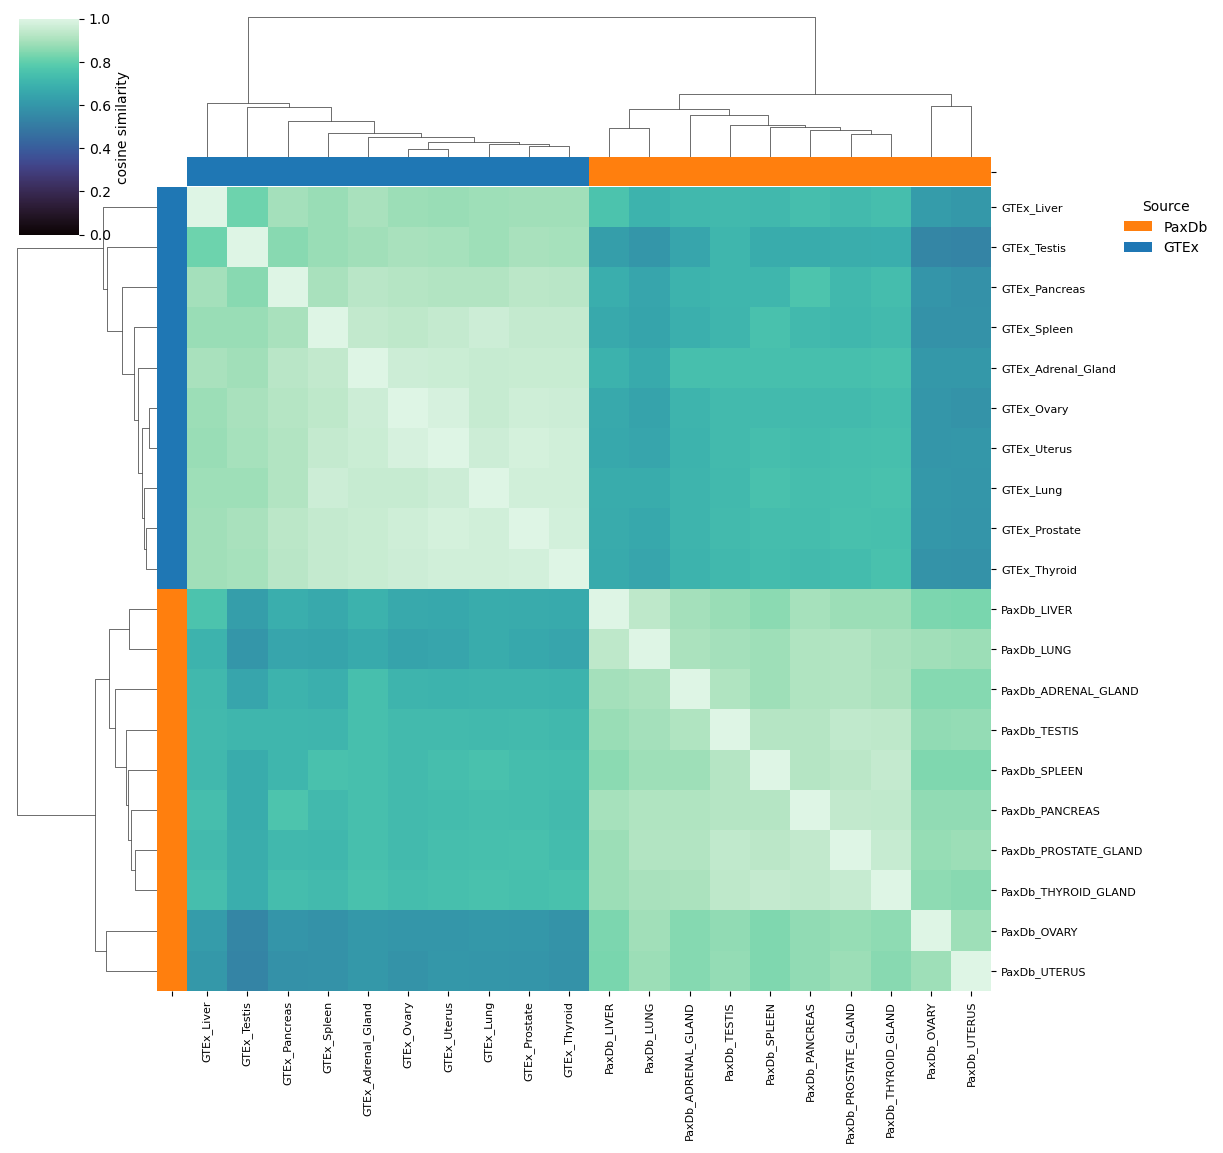

done


In [9]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage
from sklearn.metrics.pairwise import cosine_similarity

paxdb = pd.read_csv("paxdb_all_tissues.tsv", sep="\t").set_index("id")
paxdb = paxdb.fillna(0)
paxdb.columns = [f"PaxDb_{c}" for c in paxdb.columns]

gtex_raw = pd.read_csv(
    "GTEx_Analysis_2025-08-22_v11_RNASeQCv2.4.3_gene_median_tpm.gct.gz",
    sep="\t",
    skiprows=2,
)
gtex = gtex_raw.drop(columns=["Name"]).groupby("Description").sum()
gtex.index.name = "id"
gtex.columns = [f"GTEx_{c}" for c in gtex.columns]

combined = paxdb.join(gtex, how="inner")
log_combined = np.log2(combined + 1)

print(f"{combined.shape[0]} shared genes, {paxdb.shape[1]} PaxDb tissues, {gtex.shape[1]} GTEx tissues")
print("any NaN in combined:", combined.isna().any().any())

PAXDB_TO_GTEX = {
    "ADRENAL_GLAND": "Adrenal_Gland",
    "LIVER": "Liver",
    "LUNG": "Lung",
    "OVARY": "Ovary",
    "PANCREAS": "Pancreas",
    "PROSTATE_GLAND": "Prostate",
    "SPLEEN": "Spleen",
    "TESTIS": "Testis",
    "THYROID_GLAND": "Thyroid",
    "UTERUS": "Uterus",
}

subset_cols = [f"PaxDb_{p}" for p in PAXDB_TO_GTEX] + [f"GTEx_{g}" for g in PAXDB_TO_GTEX.values()]
subset = log_combined[subset_cols]
print("any NaN in subset:", subset.isna().any().any())

sim = cosine_similarity(subset.T.values)
sim = pd.DataFrame(sim, index=subset_cols, columns=subset_cols)

dist = 1 - sim.values
np.fill_diagonal(dist, 0)
condensed = squareform(dist, checks=False)
tissue_linkage = linkage(condensed, method="average")

source = pd.Series(
    ["PaxDb" if c.startswith("PaxDb_") else "GTEx" for c in sim.columns],
    index=sim.columns,
)
palette = {"PaxDb": "tab:orange", "GTEx": "tab:blue"}
source_colors = source.map(palette)

g = sns.clustermap(
    sim,
    row_linkage=tissue_linkage,
    col_linkage=tissue_linkage,
    cmap="mako",
    vmin=0,
    vmax=1,
    row_colors=source_colors,
    col_colors=source_colors,
    figsize=(12, 12),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=0.15,
    cbar_kws={"label": "cosine similarity"},
)
g.ax_heatmap.tick_params(labelsize=8)

legend_handles = [Patch(facecolor=color, label=name) for name, color in palette.items()]
g.ax_heatmap.legend(
    handles=legend_handles,
    title="Source",
    loc="upper left",
    bbox_to_anchor=(1.15, 1.0),
    bbox_transform=g.ax_heatmap.transAxes,
    frameon=False,
)

g.savefig("paxdb_gtex_tissue_clustermap.pdf")
plt.show()
print("done")


18749 shared genes, 52 PaxDb tissues, 68 GTEx tissues


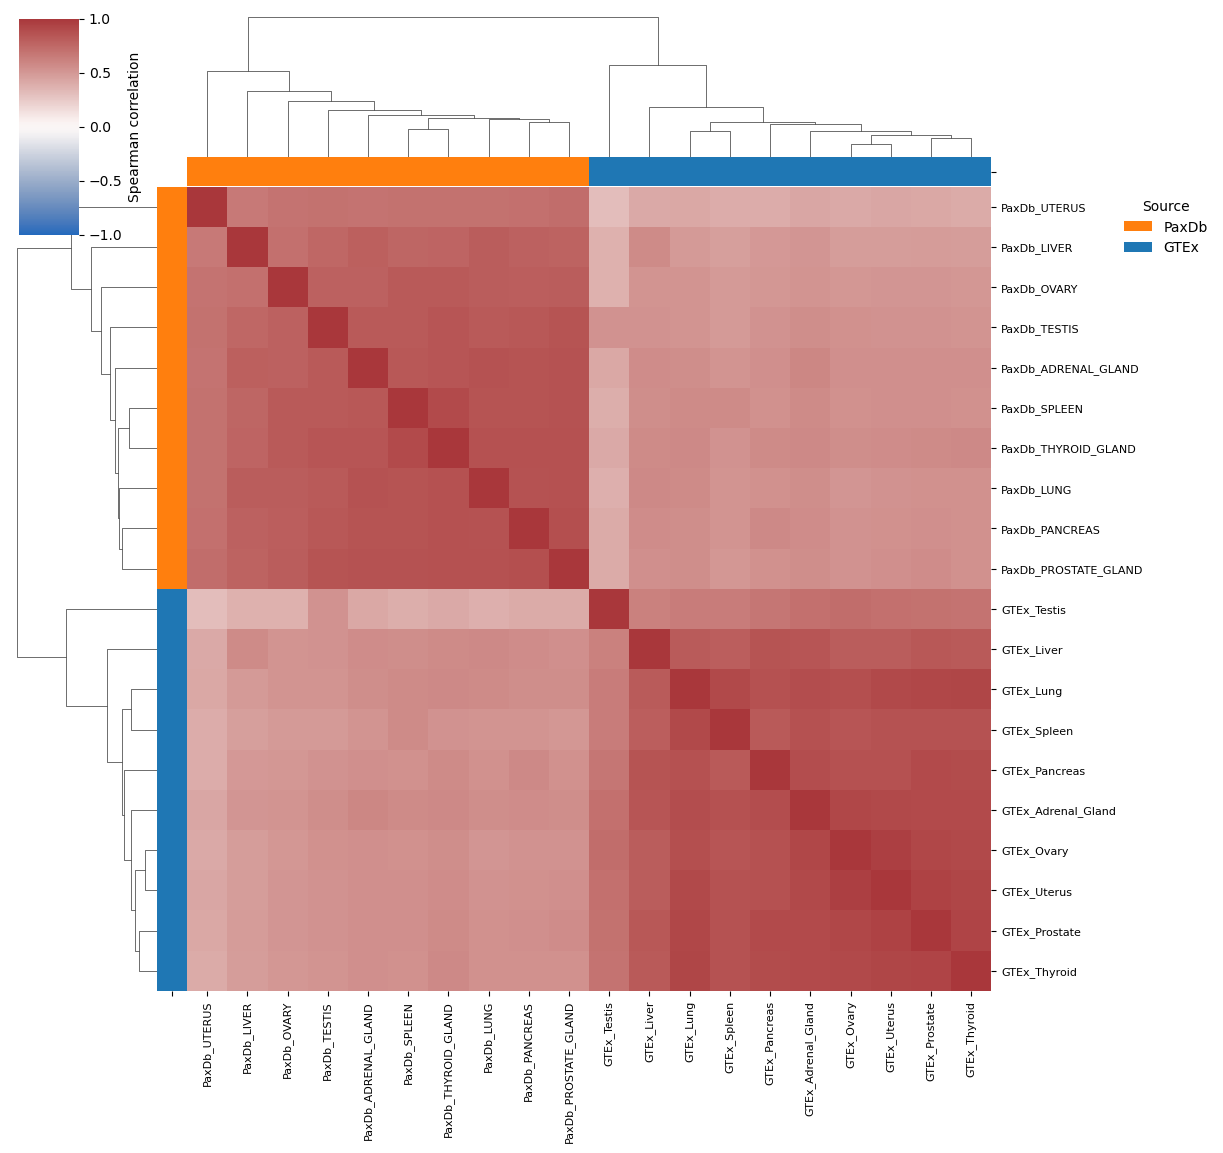

done


In [13]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

paxdb = pd.read_csv("paxdb_all_tissues.tsv", sep="\t").set_index("id")
paxdb = paxdb.fillna(0)
paxdb.columns = [f"PaxDb_{c}" for c in paxdb.columns]

gtex_raw = pd.read_csv(
    "GTEx_Analysis_2025-08-22_v11_RNASeQCv2.4.3_gene_median_tpm.gct.gz",
    sep="\t",
    skiprows=2,
)
gtex = gtex_raw.drop(columns=["Name"]).groupby("Description").sum()
gtex.index.name = "id"
gtex.columns = [f"GTEx_{c}" for c in gtex.columns]

combined = paxdb.join(gtex, how="inner")
log_combined = np.log2(combined + 1)

print(f"{combined.shape[0]} shared genes, {paxdb.shape[1]} PaxDb tissues, {gtex.shape[1]} GTEx tissues")

PAXDB_TO_GTEX = {
    "ADRENAL_GLAND": "Adrenal_Gland",
    "LIVER": "Liver",
    "LUNG": "Lung",
    "OVARY": "Ovary",
    "PANCREAS": "Pancreas",
    "PROSTATE_GLAND": "Prostate",
    "SPLEEN": "Spleen",
    "TESTIS": "Testis",
    "THYROID_GLAND": "Thyroid",
    "UTERUS": "Uterus",
}

subset_cols = [f"PaxDb_{p}" for p in PAXDB_TO_GTEX] + [f"GTEx_{g}" for g in PAXDB_TO_GTEX.values()]
subset = log_combined[subset_cols]

sim = subset.corr(method="spearman")

dist = 1 - sim.values
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2
condensed = squareform(dist, checks=False)
tissue_linkage = linkage(condensed, method="average")

source = pd.Series(
    ["PaxDb" if c.startswith("PaxDb_") else "GTEx" for c in sim.columns],
    index=sim.columns,
)
palette = {"PaxDb": "tab:orange", "GTEx": "tab:blue"}
source_colors = source.map(palette)

g = sns.clustermap(
    sim,
    row_linkage=tissue_linkage,
    col_linkage=tissue_linkage,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    row_colors=source_colors,
    col_colors=source_colors,
    figsize=(12, 12),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=0.15,
    cbar_kws={"label": "Spearman correlation"},
)
g.ax_heatmap.tick_params(labelsize=8)

legend_handles = [Patch(facecolor=color, label=name) for name, color in palette.items()]
g.ax_heatmap.legend(
    handles=legend_handles,
    title="Source",
    loc="upper left",
    bbox_to_anchor=(1.15, 1.0),
    bbox_transform=g.ax_heatmap.transAxes,
    frameon=False,
)

g.savefig("paxdb_gtex_tissue_clustermap.pdf")
plt.show()
print("done")
